# Phase 3 — GENIE BPC external validation (all 5 solid tumors)

Figures for the **frozen** model (fit on MSK train+val, zero retraining) applied to the **5 solid
tumors** in patients from NON-MSK centers (DFCI / VICC / UHN). Reads the
`results/external_genie_<tumor>.json` files (Phase 3) and `results/embedding_grid__medgemma15.json`
(Phase 1, internal MSK test) — it **does not recompute** anything.

Three figures:
1. **External C-index forest** per tumor (`tab` vs `both`) — does the frozen model generalize outside MSK?
2. **Embedding contribution (`both − tab`): internal vs external** — where does the semantic signal transfer?
3. **Adjusted HR forest** (risk per +1 SD, adjusted for age + stage) per tumor.

PNGs in `data/processed/figures/` (gitignored); they stay embedded in this `.ipynb`.
Convention: all labels, comments and narrative in English.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Run from repo root or notebooks/ -- resolve either way.
ROOT = Path.cwd()
ROOT = ROOT if (ROOT / 'results').exists() else ROOT.parent
FIGDIR = ROOT / 'data/processed/figures'  # gitignored; PNGs live here
FIGDIR.mkdir(parents=True, exist_ok=True)

# cohort file stem -> (display label, MSK CANCER_TYPE used for the Phase-1 lookup)
COHORTS = {
    'panc':     ('Pancreas',   'Pancreatic Cancer'),
    'prostate': ('Prostate',   'Prostate Cancer'),
    'crc':      ('Colorectal', 'Colorectal Cancer'),
    'brca':     ('Breast',     'Breast Cancer'),
    'nsclc':    ('NSCLC',      'Non-Small Cell Lung Cancer'),
}

internal = json.loads((ROOT / 'results/embedding_grid__medgemma15.json').read_text())
int_tab   = internal['feature_sets']['tab']['c_index_per_cancer_test']
int_both  = internal['feature_sets']['both']['c_index_per_cancer_test']
int_delta = internal['delta_per_cancer_test']['both_minus_tab']  # bootstrap CI per tumor

rows = []
for stem, (label, ct) in COHORTS.items():
    ext = json.loads((ROOT / f'results/external_genie_{stem}.json').read_text())
    ft, fb = ext['feature_sets']['tab'], ext['feature_sets']['both']
    hr, dl = fb['cox_adjusted_hr'], int_delta[ct]
    rows.append({
        'tumor': label, 'n_ext': ext['external_n'], 'events': fb['events'],
        'f1_tab': int_tab[ct], 'f1_both': int_both[ct],
        'f1_lo': dl['ci_low'], 'f1_hi': dl['ci_high'], 'f1_p': dl['p_gt0'],
        'f3_tab': ft['concordance'], 'f3_both': fb['concordance'],
        'hr': hr['hr_per_sd'], 'hr_lo': hr['ci_low'], 'hr_hi': hr['ci_high'], 'hr_p': hr['p'],
    })
df = pd.DataFrame(rows)
df['f1_d'] = df['f1_both'] - df['f1_tab']   # internal embedding lift (point)
df['f3_d'] = df['f3_both'] - df['f3_tab']   # external embedding lift (point)
df.round(4)

,tumor,n_ext,events,f1_tab,f1_both,f1_lo,f1_hi,f1_p,f3_tab,f3_both,hr,hr_lo,hr_hi,hr_p,f1_d,f3_d
0,Pancreas,551,470,0.6494,0.6879,0.0200,0.0583,1.000,0.7150,0.7253,1.6684,1.5028,1.8523,0.0,0.0386,0.0103
1,Prostate,517,194,0.7707,0.7875,-0.0121,0.0468,0.877,0.6559,0.6946,1.4111,1.2303,1.6185,0.0,0.0168,0.0387
2,Colorectal,776,386,0.7399,0.7499,-0.0079,0.0274,0.853,0.7137,0.7145,1.4798,1.3368,1.6380,0.0,0.0100,0.0007
3,Breast,596,345,0.7821,0.7945,-0.0063,0.0326,0.889,0.6826,0.6786,1.6883,1.4999,1.9005,0.0,0.0125,-0.0040
4,NSCLC,955,569,0.7349,0.7367,-0.0111,0.0144,0.631,0.7180,0.6820,1.4095,1.3033,1.5242,0.0,0.0018,-0.0360


## Figure 1 — External C-index forest per tumor (`tab` vs `both`)

Each row is a tumor; the gray point is `tab` (12 features) and the blue one is `both` (+ MedGemma),
joined by a line. All to the right of 0.5 (chance) = **the frozen model discriminates outside MSK in
all 5**. The number at the end is the embedding contribution (`both − tab`): green if it adds, red if
it subtracts.

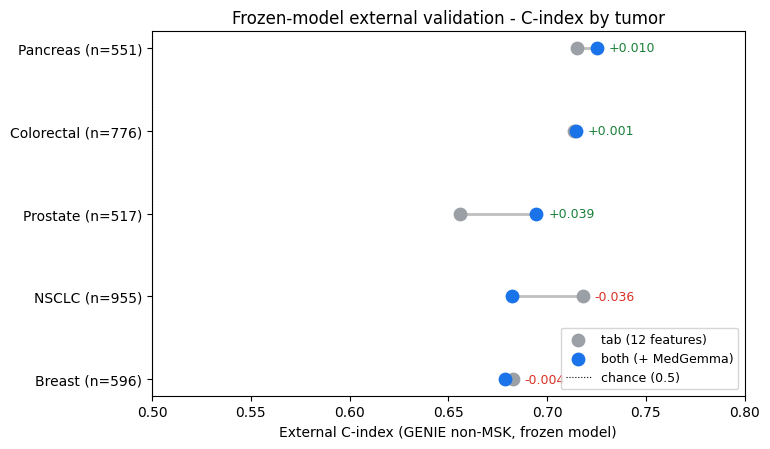

In [2]:
order = df.sort_values('f3_both').reset_index(drop=True)  # weakest at bottom
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.hlines(y, order['f3_tab'], order['f3_both'], color='0.75', lw=2, zorder=1)
ax.scatter(order['f3_tab'],  y, s=80, color='#9aa0a6', label='tab (12 features)', zorder=2)
ax.scatter(order['f3_both'], y, s=80, color='#1a73e8', label='both (+ MedGemma)', zorder=2)
for yi, r in order.iterrows():
    d = r['f3_d']
    ax.text(max(r['f3_tab'], r['f3_both']) + 0.006, yi, f"{d:+.3f}",
            va='center', fontsize=9, color='#188038' if d > 0 else '#d93025')
ax.axvline(0.5, ls=':', c='k', lw=0.8, label='chance (0.5)')
ax.set_yticks(y)
ax.set_yticklabels([f"{t} (n={int(n)})" for t, n in zip(order['tumor'], order['n_ext'])])
ax.set_xlabel('External C-index (GENIE non-MSK, frozen model)')
ax.set_xlim(0.5, 0.80)
ax.set_title('Frozen-model external validation - C-index by tumor')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_external_forest_cindex.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Embedding contribution (`both − tab`): internal vs external

The blue point is the contribution on the **internal MSK test** (with the Phase 1 bootstrap 95% CI);
the red square is the contribution on the **external** cohort (point estimate; there is no external
bootstrap yet). Vertical line at 0 = no contribution. Where both fall clearly to the right of 0
(pancreas, prostate) the LM's semantic signal **transfers**; NSCLC is the case where the embedding
subtracts outside MSK.

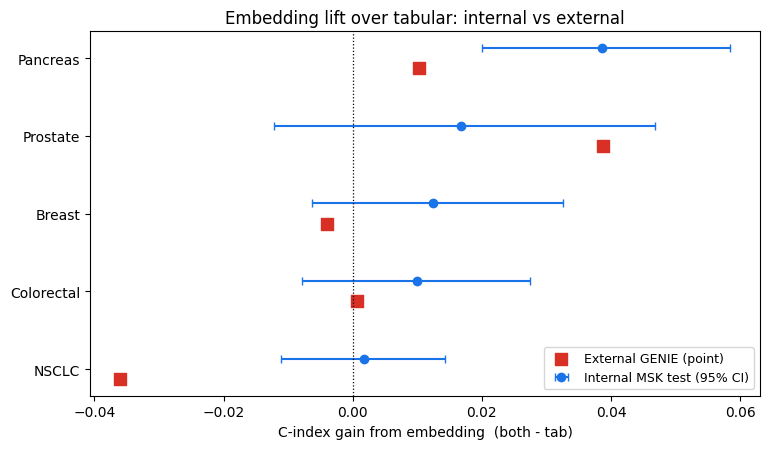

In [3]:
order = df.sort_values('f1_d').reset_index(drop=True)
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.errorbar(order['f1_d'], y + 0.13,
            xerr=[order['f1_d'] - order['f1_lo'], order['f1_hi'] - order['f1_d']],
            fmt='o', color='#1a73e8', capsize=3, label='Internal MSK test (95% CI)')
ax.scatter(order['f3_d'], y - 0.13, marker='s', s=70, color='#d93025',
           label='External GENIE (point)')
ax.axvline(0, ls=':', c='k', lw=0.9)
ax.set_yticks(y); ax.set_yticklabels(order['tumor'])
ax.set_xlabel('C-index gain from embedding  (both - tab)')
ax.set_title('Embedding lift over tabular: internal vs external')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_external_delta_internal_vs_external.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Adjusted risk HR forest (`both` model) per tumor

Hazard ratio per **+1 SD** of the frozen model's risk, **adjusted for age + stage**, with 95% CI
(log scale). Red line at HR = 1 (no effect). All > 1 with a CI that excludes 1 = the LM risk is a
**robust prognostic factor** in every external tumor — it not only discriminates (C-index) but
stratifies hazard.

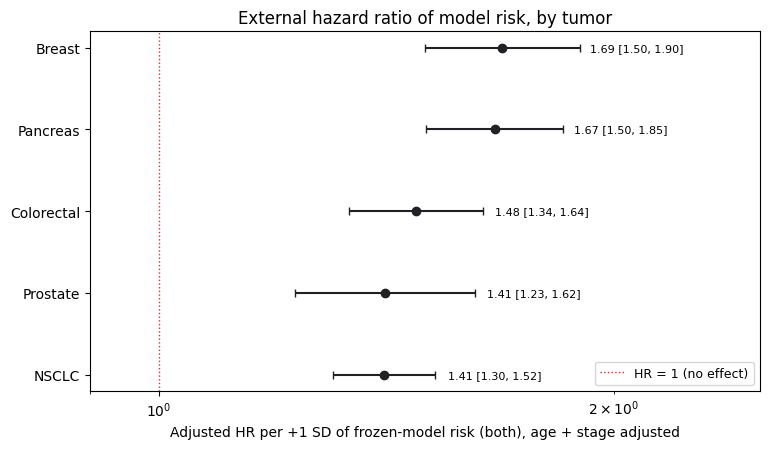

In [4]:
order = df.sort_values('hr').reset_index(drop=True)
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.errorbar(order['hr'], y,
            xerr=[order['hr'] - order['hr_lo'], order['hr_hi'] - order['hr']],
            fmt='o', color='#202124', capsize=3)
ax.axvline(1.0, ls=':', c='#d93025', lw=1.0, label='HR = 1 (no effect)')
for yi, r in order.iterrows():
    ax.text(r['hr_hi'] + 0.03, yi, f"{r['hr']:.2f} [{r['hr_lo']:.2f}, {r['hr_hi']:.2f}]",
            va='center', fontsize=8)
ax.set_xscale('log')
ax.set_yticks(y); ax.set_yticklabels(order['tumor'])
ax.set_xlabel('Adjusted HR per +1 SD of frozen-model risk (both), age + stage adjusted')
ax.set_xlim(0.9, float(order['hr_hi'].max()) + 0.6)
ax.set_title('External hazard ratio of model risk, by tumor')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_external_hr_forest.png', dpi=150, bbox_inches='tight')
plt.show()

## Reading

- **Generalizes without leakage in all 5:** the frozen model (MSK train+val) keeps a C-index ≥ 0.65 in
  both `tab` and `both` on external non-MSK cohorts (DFCI/VICC/UHN) across all 5 tumors → real external
  validation.
- **The embedding contribution is NOT uniform** (consistent with Phase 1): positive and consistent in
  **pancreas** (+0.039 int → +0.010 ext) and **prostate** (+0.039 ext, the largest; it recovers what
  `tab` loses outside MSK); ~neutral in colorectal/breast; **negative in NSCLC** (−0.036 ext) → caveat
  (divergent gene panels → more OOV in the tabular/embedding branch).
- **Robust adjusted HR:** the model's risk is prognostic (HR/SD > 1, CI excludes 1) in every external
  tumor after adjusting for age + stage.
- **Comparison caveat:** Phase 1 = internal test, same origin; Phase 3 = independent cohort (non-MSK, OS
  with a possible time shift). The `tab` drops from P1→P3 (breast, prostate) are expected domain shift;
  what is informative is how the embedding contribution behaves under that shift.